In [1]:
import time
import numpy as np                        # for manipulating arrays
from specutils import Spectrum1D          # spectrum data model
import json                               # to pretty-print dicts
from astropy import units as u            # astropy utilities
from astropy.coordinates import SkyCoord
from astropy.table import Table
from matplotlib import pyplot as plt      # visualization libs
from IPython.display import display
%matplotlib inline
from getpass import getpass
from dl import authClient as ac, queryClient as qc #, storeClient as sc
from dl.helpers.utils import convert

In [2]:
token = ac.login(input("Enter user name: (+ENTER) "),getpass("Enter password: (+ENTER) "))
ac.whoAmI()
if not ac.isValidToken(token):
    print('Error: invalid login for user %s (%s)' % (username,token))
else:
    print("Login token:   %s" % token)

Enter user name: (+ENTER)  varelanibal
Enter password: (+ENTER)  ········


Login token:   varelanibal.3772.3772.$1$ksendZlF$OwBWlJZ3Fbhx0tNC3WvkO/


In [17]:
import numpy as np
import os, sys, re, copy, math
import pandas as pd
from pathlib import Path
# Get the directory where the script is located
# script_dir = Path(__file__).parent
# # print(script_dir)
# home_dir = os.path.expanduser("~")
sys.path.append('/home/anibal/microlensing/simulation_Rubin/roman_rubin/')
# from bandpass import Bandpass
# from signaltonoise import calc_mag_error_m5
# from photometric_parameters import PhotometricParameters
from rubin_sim.phot_utils.photometric_parameters import PhotometricParameters
from rubin_sim.phot_utils.signaltonoise import calc_mag_error_m5
from rubin_sim.phot_utils.bandpass import Bandpass
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
#astropy
import astropy.units as u
from astropy.table import QTable
from astropy.time import Time
from astropy.coordinates import SkyCoord
# --- Fix para IERS y sidereal_time de Astropy ---
from astropy.utils import iers
iers.conf.auto_max_age = None
iers.conf.auto_download = False  # No intenta descargar
iers.conf.iers_degraded_accuracy = 'warn'
#pyLIMA
from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.toolbox import time_series
from pyLIMA.simulations import simulator
from pyLIMA.models import PSBL_model
from pyLIMA.models import USBL_model
from pyLIMA.models import FSPLarge_model
from pyLIMA.models import PSPL_model
from pyLIMA.fits import TRF_fit
from pyLIMA.fits import DE_fit
from pyLIMA.fits import MCMC_fit
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.outputs import file_outputs

from ulens_params import microlensing_params, event_param, event_param2
import multiprocessing as mul
import h5py
from detection_criteria import filter5points, deviation_from_constant, has_consecutive_numbers, filter_band, mag
from read_save import save_sim, save_fit, read_data




def telescope_rubin(name_event,Ra, Dec):
    '''
    name_event (str): name of the event
    Ra (float): Ra coordinate of the event
    Dec (float): Dec coordinate of the event
    '''

    LSST_BandPass = {}
    lsst_filterlist = 'ugrizy'
    for f in lsst_filterlist:
        LSST_BandPass[f] = Bandpass()
        path_che = '/home/anibal/rubin_sim_data/throughputs/baseline/'
        LSST_BandPass[f].read_throughput(path_che + f'total_{f}.dat')
    baseline_file = get_baseline() #last baseline
    conn = baseline_file
    outDir = 'temp'
    resultsDb = maf.db.ResultsDb()
    metric = maf.metrics.PassMetric(cols=['filter', 'observationStartMJD', 'fiveSigmaDepth'])
    slicer = maf.slicers.UserPointsSlicer(ra=[Ra], dec=[Dec])
    sql = ''
    metric_bundle = maf.MetricBundle(metric, slicer, sql)
    bundleDict = {'my_bundle': metric_bundle}
    bg = maf.MetricBundleGroup(bundleDict, conn, out_dir=outDir, results_db=resultsDb)
    bg.run_all()
    dataSlice = metric_bundle.metric_values[0]
    
    rubin_ts = {}
    for fil in lsst_filterlist:
        m5 = dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == fil)]
        mjd = dataSlice['observationStartMJD'][np.where(dataSlice['filter'] == fil)] + 2400000.5
        int_array = np.column_stack((mjd, m5, m5)).astype(float)
        rubin_ts[fil] = int_array

    my_own_creation = event.Event(ra=Ra, dec=Dec)
    my_own_creation.name = 'ulens_event'

    for band in lsst_filterlist:
        lsst_telescope = telescopes.Telescope(name=band, camera_filter=band, location='Earth',
                                              lightcurve=rubin_ts[band],
                                              lightcurve_names=['time', 'mag', 'err_mag'],
                                              lightcurve_units=['JD', 'mag', 'mag'])
        my_own_creation.telescopes.append(lsst_telescope)

    return my_own_creation, dataSlice, LSST_BandPass

def set_photometric_parameters(exptime, nexp, readnoise=None):
    # readnoise = None will use the default (8.8 e/pixel). Readnoise should be in electrons/pixel.
    photParams = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=readnoise)
    return photParams

def sim_event(i, data, model):
    '''
    i (int): index of the TRILEGAL data set
    data (dictionary): parameters including magnitude of the stars
    path_ephemerides (str): path to the ephemeris of Gaia
    path_dataslice(str): path to the dataslice obtained from OpSims
    model(str): model desired
    '''
    
    magstar = {'u': data["u"], 'g': data["g"], 'r': data["r"],
               'i': data["i"], 'z': data["z"], 'y': data["Y"]}
    
    ZP = { 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}
    Ra, Dec = data['ra'], data['dec']
    my_own_creation, dataSlice, LSST_BandPass = telescope_rubin(i,Ra, Dec)
    photParams = set_photometric_parameters(15, 2)
    new_creation = copy.deepcopy(my_own_creation)
    np.random.seed(i)
    t0 = data['t0']
    tE = data['tE']

    if model == 'USBL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'], 'rho': data['rho'],
                  's': data['s'], 'q': data['q'], 'alpha': data['alpha'],
                  'piEN': data['piEN'], 'piEE': data['piEE']}
        choice = np.random.choice(["central_caustic", "second_caustic", "third_caustic"])
        # usbl = pyLIMA.models.USBL_model.USBLmodel(roman_event, origin=[choice, [0, 0]],blend_flux_parameter='ftotal')
        my_own_model = USBL_model.USBLmodel(new_creation, origin=[choice, [0, 0]],
                                            blend_flux_parameter='ftotal',
                                            parallax=['Full', t0])
    elif model == 'USBL_NoPiE':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'], 'rho': data['rho'],
          's': data['s'], 'q': data['q'], 'alpha': data['alpha']}
        
        choice = np.random.choice(["central_caustic", "second_caustic", "third_caustic"])
        my_own_model = USBL_model.USBLmodel(new_creation, origin=[choice, [0, 0]],
                                    blend_flux_parameter='ftotal')

    elif model == 'FSPL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'],
                  'rho': data['rho'], 'piEN': data['piEN'],
                  'piEE': data['piEE']}
        my_own_model = FSPLarge_model.FSPLargemodel(new_creation, parallax=['Full', t0])
    elif model == 'PSPL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'],
                  'piEN': data['piEN'], 'piEE': data['piEE']}
        my_own_model = PSPL_model.PSPLmodel(new_creation, parallax=['Full', t0])
    elif model == 'PSPL_NoPiE':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['tE'],
                  'piEN': data['piEN'], 'piEE': data['piEE']}
        my_own_model = PSPL_model.PSPLmodel(new_creation)

    my_own_parameters = []
    for key in params:
        my_own_parameters.append(params[key])

    my_own_flux_parameters = []
    fs, G, F = {}, {}, {}
    # np.random.seed(i)
    for band in magstar:
        flux_baseline = 10 ** ((ZP[band] - magstar[band]) / 2.5)
        g = np.random.uniform(0, 1)
        f_source = flux_baseline / (1 + g)
        fs[band] = f_source
        G[band] = g
        F[band] = f_source + g * f_source  # flux_baseline
        f_total = f_source * (1 + g)
        if my_own_model.blend_flux_parameter == "ftotal":
            my_own_flux_parameters.append(f_source)
            my_own_flux_parameters.append(f_total)
        else:
            my_own_flux_parameters.append(f_source)
            my_own_flux_parameters.append(f_source * g)

    my_own_parameters += my_own_flux_parameters
    pyLIMA_parameters = my_own_model.compute_pyLIMA_parameters(my_own_parameters)
    simulator.simulate_lightcurve(my_own_model, pyLIMA_parameters)

    for k in range(1, len(new_creation.telescopes)):
        model_flux = my_own_model.compute_the_microlensing_model(new_creation.telescopes[k],
                                                                 pyLIMA_parameters)['photometry']
        new_creation.telescopes[k].lightcurve['flux'] = model_flux

    Rubin_band = False
    for telo in new_creation.telescopes:
        X = telo.lightcurve['time'].value
        ym = mag(ZP[telo.name], telo.lightcurve['flux'].value)
        z, y, x, M5 = [], [], [], []
        for k in range(len(ym)):
            m5 = dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == telo.name)][k]
            magerr = calc_mag_error_m5(ym[k], LSST_BandPass[telo.name], m5, photParams)[0]
            z.append(magerr)
            y.append(np.random.normal(ym[k], magerr))
            x.append(X[k])
            M5.append(m5)
        data = QTable([telo.lightcurve['err_flux'].value, np.array(z), telo.lightcurve['flux'].value,
                       telo.lightcurve['inv_err_flux'].value, np.array(M5), np.array(y), np.array(x)],
                      names=('err_flux', 'err_mag', 'flux', 'inv_err_flux', 'm5', 'mag', 'time'))
        
        telo.lightcurve = filter_band(data, m5, telo.name)
        if not len(telo.lightcurve['mag']) == 0:
            Rubin_band = True
    # This first if holds for an event with at least one Roman and Rubin band
    if Rubin_band:
        # This second if holds for a "detectable" event to fit
        if filter5points(pyLIMA_parameters, new_creation.telescopes) and deviation_from_constant(pyLIMA_parameters, new_creation.telescopes):
            print("A good event to fit")
            return my_own_model, pyLIMA_parameters, True
        else:
            print(
                "Not a good event to fit.\nFail 5 points in t0+-tE\nNot have 3 consecutives points that deviate from constant flux in t0+-tE")
            return my_own_model, pyLIMA_parameters, False
    else:
        print("Not a good event to fit since no Rubin band")
        return my_own_model, pyLIMA_parameters, False


def sim_rubin_event(i, system_type, model, TRILEGAL_row, path_to_save_model):
    
    seed = i
    
    magstar = TRILEGAL_row
    event_params = {**magstar, 
                    **event_param2(i, TRILEGAL_row, system_type)}
     
    my_own_model, pyLIMA_parameters, decision = sim_event(i, event_params, model)

    return my_own_model, pyLIMA_parameters, decision

In [4]:
ra_center = 266
dec_center = -29.0
radius = 0.1   # degrees

query = f"""
SELECT *
FROM lsst_sim.simdr2
WHERE q3c_radial_query(ra, dec, {ra_center}, {dec_center}, {radius})
LIMIT 1
"""

res = qc.query(sql=query,format='csv')
df = convert(res,'pandas')

In [5]:
# df.columns

In [5]:
DS = 10**((df['mu0'] + 5)/5)
DL = np.random.uniform(1,DS)
mu_rel =np.sqrt(df['pmracosd']**2 + df['pmdec']**2) #it's actually mu_S mu_rel=mu_s-mu_L

TRILEGAL_data = {"D_S":DS.iloc[0],
                 "D_L":DL[0],
                 "mu_rel":mu_rel.iloc[0],
                 "logL":df["logl"].iloc[0],
                 "logTe":df["logte"].iloc[0],
                 "ra":df["ra"].iloc[0],
                 "dec":df["dec"].iloc[0],
                 "u":df["umag"].iloc[0],
                 "g":df["gmag"].iloc[0],
                 "r":df["rmag"].iloc[0],
                 "i":df["imag"].iloc[0],
                 "z":df["zmag"].iloc[0],
                 "Y":df["ymag"].iloc[0]                
}

In [29]:
TRILEGAL_row = df
i=425
model ='PSPL'
system_type = 'BH'
path_to_save_model = '/home/anibal/'
my_own_model, pyLIMA_parameters, decision = sim_rubin_event(i, system_type, model, TRILEGAL_data ,path_to_save_model)

Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
A good event to fit


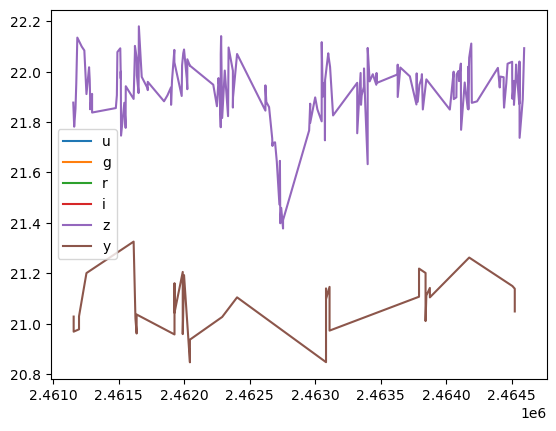

In [30]:
for tel in my_own_model.event.telescopes:
    plt.plot(tel.lightcurve['time'],tel.lightcurve['mag'],label=tel.name)

plt.legend()